# 基于 vLLM 的视觉语言模型 OCR 教程

## 概述

本 Notebook 提供分步指南，演示如何结合 **视觉语言模型（Vision-Language Model, VLM）**、**vLLM** 与 **Gradio**，构建一套可用于推理的光学字符识别（Optical Character Recognition, OCR）系统。广泛应用于商品信息自动录入、试卷的自动批改与录入、扫描全能王类的APP等。

OCR 是从图像、扫描文档及手写内容中提取文本的关键技术。视觉语言模型基于 Transformer 架构，能够进行上下文感知的文本识别，从而显著增强传统 OCR 能力。

本教程带你在 AMD Radeon GPU 云平台（radeon.anruicloud.com）上的Jupyter Notebook 内完成依赖安装、识别图片中的文字。

> **说明**：关于 AMD Radeon Cloud 平台：该平台提供预装 ROCm 的 Docker 容器环境，通过 Jupyter Lab 访问。由于平台只对外暴露 Jupyter 的 8888 端口，本教程最后会通过 cloudflared 建一条出站隧道，通过浏览器访问 Web UI。

本教程以 Qwen2-VL-2B-Instruct 模型为例，讲解 OCR 场景的实践方法，主要涵盖：

- 基于 Docker 与 ROCm 的环境配置
- 在容器内启动 Jupyter Notebook
- 安装依赖
- 使用 vLLM 构建 OCR 推理流程
- 扩展为支持多模型选择的图形界面（GUI）系统

本教程采用 **vLLM** 作为大语言模型（Large Language Model, LLM）推理引擎。vLLM 通过高效请求批处理（batching）与 GPU 资源调度，优化文本生成工作负载，实现高吞吐、低延迟，适用于聊天机器人等交互式应用。



## 前置条件

本教程在以下环境开发并验证

### 操作系统

- **Ubuntu 24.04.4 LTS**。使用命令查询os的版本:cat /etc/os-release。Radeon 上的 ROCm 7.2.x 目前仅支持 Ubuntu 24.04.4、Ubuntu 22.04.5、RHEL 10.1、RHEL 9.7。

### 硬件

- **AMD Radeon AI PRO W7900**：本教程在 **AMD Radeon AI PRO W7900**（RDNA3，gfx1100，48GB 显存）上完成测试。其他受支持型号包括 RX 7900 XT / GRE、RX 9070 XT / GRE / 9070、RX 9060 XT、PRO W7900 / W7800 等。请确认你的卡在 ROCm Radeon 兼容性矩阵 内。https://rocm.docs.amd.com/projects/install-on-linux/en/latest/reference/system-requirements.html
- 只能在**容器里**使用该命令查询当前使用的GPU架构代号：

In [ ]:
!rocminfo | grep -E 'Name:|Marketing Name:|Device Type:|gfx'

  Name:                    AMD EPYC 9334 32-Core Processor    
  Marketing Name:          AMD EPYC 9334 32-Core Processor    
  Vendor Name:             CPU                                
  Device Type:             CPU                                
  Name:                    AMD EPYC 9334 32-Core Processor    
  Marketing Name:          AMD EPYC 9334 32-Core Processor    
  Vendor Name:             CPU                                
  Device Type:             CPU                                
  Name:                    gfx1100                            
  Marketing Name:          AMD Radeon Graphics                
  Vendor Name:             AMD                                
  Device Type:             GPU                                
      Name:                    amdgcn-amd-amdhsa--gfx1100         
      Name:                    amdgcn-amd-amdhsa--gfx11-generic   


### 软件

- **ROCm 7.2.4**：按 [ROCm 安装指南](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/install/quick-start.html) 安装并验证。安装完成后，执行以下命令确认环境,该命令将列出 AMD GPU 及相关详细信息：
> **说明**：若使用 ROCm 6.4 及更早版本，请改用 `rocm-smi` 命令。

In [ ]:
!amd-smi

+------------------------------------------------------------------------------+
| AMD-SMI 26.2.2+e1a6bc5663    amdgpu version: 6.14.14  ROCm version: 7.2.1    |
| VBIOS version: 00162356                                                      |
| Platform: Linux Baremetal                                                    |
|-------------------------------------+----------------------------------------|
| BDF                        GPU-Name | Mem-Uti   Temp   UEC       Power-Usage |
| GPU  HIP-ID  OAM-ID  Partition-Mode | GFX-Uti    Fan               Mem-Usage |
|=====================================+========================================|
| 0000:63:00.0    AMD Radeon Graphics | 0 %      32 °C   0            13/241 W |
|   0       0     N/A             N/A | 0 %     20.0 %             26/49136 MB |
+-------------------------------------+----------------------------------------+
+------------------------------------------------------------------------------+
| Processes:                

## 一. 宿主机准备推理环境

> **说明**：若此时在docker 容器/Jupyter notebook/Radeon cloud 提供的实例中无需执行**此**步骤。

### 1.安装docker
请参照对应操作系统的 Docker 安装文档:https://docs.docker.com/engine/install/ubuntu/       
确保 Docker 已正确安装与配置。
> **说明**：请正确配置 Docker 权限。若需允许非 root 用户访问 Docker，如下操作:
  
**root用户登录宿主机**：
> **说明**：目的是让把 '个人用户名' 加进 docker 组(需要 root/sudo)。
```bash
sudo usermod -aG docker 个人用户名
```
**个人用户登录宿主机**：
> **说明**：目的是让普通用户能够免 sudo 直接使用 docker。
```bash
newgrp docker
```         
**验证 Docker 是否正常工作**：  
```bash
docker run hello-world
```
> **说明**：输出`Status: Downloaded newer image for hello-world:latest
Hello from Docker!`表示正常工作。

### 2.宿主机上创建 Docker容器
**创建+启动 Docker 容器**：
```bash
docker run -d -it \
  --name OCR_rocm7.2.4 \
  --device=/dev/kfd \
  --device=/dev/dri \
  --group-add video \
  --cap-add=SYS_PTRACE \
  --security-opt seccomp=unconfined \
  --ipc=host \
  --shm-size=16g \
  -v "$HOME/OCR_rocm7.2.4:/workspace/repo" \
  -w /workspace/repo \
  -p 8888:8888 \
  --env MODELSCOPE_CACHE=/workspace/modelscope \
  rocm/pytorch:rocm7.2.4_ubuntu24.04_py3.12_pytorch_release_2.10.0 \
  bash 
```
**进入容器**：
```bash
docker exec -it <容器名/ID> bash     
```
进入容器运行 `python -c "import torch; print(torch.cuda.is_available())` 验证一下：返回 `True`,说明GPU可以获取。

> **说明**：
- 可通过该命令`systemd-detect-virt`查询是否在docker里面,结果返回`docker`,说明在docker里面.
- 上述命令`-v`把宿主机的目录挂载到容器里 `/workspace/repo`。
- **-p 宿主机端口:容器端口**：宿主机端口映射到容器端口。
- 上述命令使用的是宿主机上的镜像；也可以使用主分支下的**rocm/vllm-dev:main**,它是**Docker Hub**上的镜像坐标，从镜像仓库https://hub.docker.com/r/rocm/vllm-dev  拉取。


## 二. 在容器内启动 Jupyter Notebook

> **说明**：若此时在Jupyter notebook/Radeon cloud 提供的实例中无需执行**此**步骤。

### 1.安装jupyter
在 Docker 容器内安装 Jupyter,正常情况下Notebook已经装了Jupyter，可先判断是否已经安装，若能查询出结果表示已经安装：
**个人用户登录宿主机**：
```bash
pip list | grep jupyter
```         
> **说明**：若查询无输出，执行`pip install jupyter`安装。

### 2.启动 Jupyter 服务：

> **说明**：
> 
> 1.为什么要在容器内启动 Jupyter? 目的是用浏览器打开Jupyter在网页里写代码、点运行，Jupyter 只是编辑器 + 运行按钮。
>
> 2.Jupyter 是否已启动？`ps aux | grep -E 'jupyter|jupyter-lab|jupyterlab'`，返回有`jupyter-lab`或`jupyter notebook`进程，说明已启动。


```bash
jupyter-lab --ip=0.0.0.0 --port=8888 --no-browser --allow-root   
```
启动Jupyter后，终端输出Token 或 URL，请保存Token 或 URL，以便在浏览器中访问 Notebook。 http://IP地址:port/lab?token=xxxxx 通过该链接访问Notebook。

## 三.下载模型
本教程使用 Qwen2-VL-2B-Instruct。
- 下面用 ModelScope（魔搭社区） 下载，国内访问速度快、稳定，无需token验证。https://modelscope.cn/models/Qwen/Qwen2-VL-2B-Instruct
- 把权重下载到/workspace/repo/docs/Qwen2-VL-2B-Instruct下。

In [ ]:
!pip install -U modelscope

from modelscope import snapshot_download

model_dir = snapshot_download(
    'Qwen/Qwen2-VL-2B-Instruct',
    local_dir='/workspace/repo/docs/Qwen2-VL-2B-Instruct'
)
print('下载完成，模型路径：', model_dir)

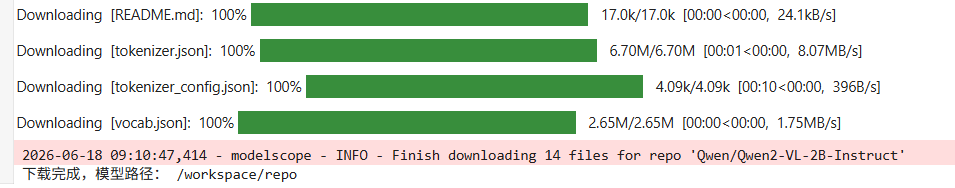

> **说明**：如果你下载的模型权重很大，可以使用其他方法快速下载，该方法的下载速度高达57MB/S。

### **workround**方法：**aria2c** 多连接直拉,视情况参考使用：
#### 1.安装aria2
```bash
apt update && apt install -y aria2
```
#### 2.装完再跑测速命令：
```bash
aria2c -x 16 -s 16 "https://modelscope.cn/models/Qwen/Qwen2-VL-2B-Instruct/resolve/master/model-00002-of-00002.safetensors" -o /tmp/speed_ms.bin
```
本教程基于aria2c下载模型的速度是57MB/s，比直接使用modelscope快近3倍。
#### 3.下载文件
```bash
%%bash
REPO="Qwen/Qwen2-VL-2B-Instruct"
REV="master"

# 1. 抓文件列表，生成 aria2 输入文件（URL + 保存路径）
curl -s "https://modelscope.cn/api/v1/models/${REPO}/repo/files?Revision=${REV}&Recursive=true" \
| python3 -c "
import sys, json
data = json.load(sys.stdin)
for f in data['Data']['Files']:
    if f['Type'] == 'blob':
        p = f['Path']
        print('https://modelscope.cn/models/${REPO}/resolve/${REV}/' + p)
        print('  out=' + p)
" > urls.txt

# 2. 交给 aria2 下载（8 线程，断点续传），如果需要可改成16线程
aria2c -x 8 -s 8 -j 4 -c --auto-file-renaming=false \
       -i urls.txt -d Qwen2-VL-2B-Instruct
```  

## 四. 安装依赖

在容器内的 Jupyter Notebook 中执行以下命令，安装本教程所需库,可先查询是否已经安装：`!pip list|grep requests`：

In [ ]:
!pip list|grep requests

requests                          2.32.5


In [ ]:
!pip install gradio

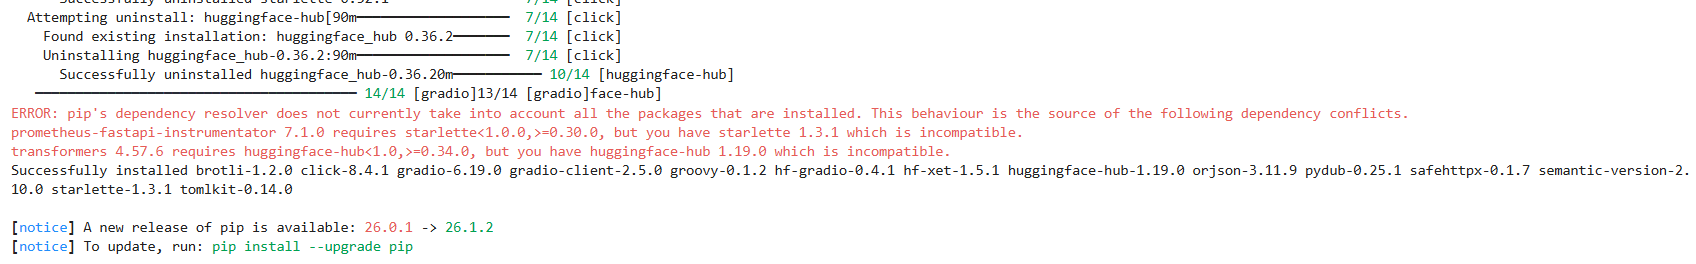

> **说明**：transformers与huggingface_hub的版本不匹配所以需要升级transformers，在升级transformers之前先查看torch版本，避免升级transformers后导致torch 版本的变动。

In [ ]:
!pip list|grep transformers

transformers                      4.57.6


In [ ]:
!pip list|grep huggingface_hub

huggingface_hub                   1.19.0


In [ ]:
!pip list|grep vllm

vllm                              0.16.1.dev0+g89a77b108.d20260317.rocm721


In [ ]:
import sys
print("python:", sys.executable)
# ROCm 版本
import subprocess
print("rocm:", subprocess.run(["bash","-c","cat /opt/rocm/.info/version 2>/dev/null || echo unknown"],
                     capture_output=True, text=True).stdout)
# torch 是不是 ROCm 版
try:
    import torch
    print("torch:", torch.__version__)        # ROCm 版会带 +rocm 后缀
    print("gpu available:", torch.cuda.is_available())
    print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
except Exception as e:
    print("torch error:", e)

python: /opt/venv/bin/python3.12
rocm: 7.2.1

torch: 2.9.1+gitff65f5b
gpu available: True
device: AMD Radeon Graphics


> **说明**：升级 transformers，用约束保证不碰 torch

In [ ]:
!echo "torch==2.9.1+gitff65f5b" > /tmp/c.txt
!pip install -U transformers -c /tmp/c.txt

> **说明**：重启kernel，并查询torch版本，确保安装transformers前后torch没有变动。

In [ ]:
import sys
print("python:", sys.executable)
# ROCm 版本
import subprocess
print("rocm:", subprocess.run(["bash","-c","cat /opt/rocm/.info/version 2>/dev/null || echo unknown"],
                     capture_output=True, text=True).stdout)
# torch 是不是 ROCm 版
try:
    import torch
    print("torch:", torch.__version__)        # ROCm 版会带 +rocm 后缀
    print("gpu available:", torch.cuda.is_available())
    print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
except Exception as e:
    print("torch error:", e)

python: /opt/venv/bin/python3.12
rocm: 7.2.1

torch: 2.9.1+gitff65f5b
gpu available: True
device: AMD Radeon Graphics


In [ ]:
!pip list|grep transformers

transformers                      5.12.1


## 五. 使用 vLLM 构建 OCR 系统

首先定义 `ImageInference` 推理类。该类通过构造函数初始化推理模型，并提供对输入图像执行推理的方法。
> **说明**：先查询下当前的所在目录，为了方便指定**current_model**的路径。

In [ ]:
import os
print(os.getcwd())

/workspace/repo


In [ ]:
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer
from PIL import Image
from vllm.multimodal.utils import fetch_image
import sys

current_model = "Qwen2-VL-2B-Instruct"
class ImageInference:
    def __init__(self, model_name=current_model):
        # Initialize the model and tokenizer
        self.llm = LLM(model=model_name, max_model_len=4096, max_num_seqs=16, enforce_eager=True)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    def generate_image_output(self, image: Image) -> str:
        messages = [{
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": (
                    "Act as an OCR assistant. Analyze the provided image and:\n"
                    "1. Identify and transcribe all visible text in the image exactly as it appears.\n"
                    "2. Preserve the original line breaks, spacing, and formatting from the image.\n"
                    "3. Output only the transcribed text, line by line, without adding any commentary or explanations or special characters.\n"
                )},
            ],
        }]
        prompt = self.tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
    
        sampling_params = SamplingParams(max_tokens=512, temperature=0.0)
    
        outputs = self.llm.generate({
            "prompt": prompt,
            "multi_modal_data": {"image": image},
        }, sampling_params=sampling_params)
    
        return outputs[0].outputs[0].text if outputs else "No output generated."

### 测试 OCR 系统

执行以下命令下载[测试图像](https://github.com/ROCm/gpuaidev/tree/main/docs/notebooks/assets/together_we_advance_.png)：

In [ ]:
import requests

url = "https://raw.githubusercontent.com/ROCm/gpuaidev/main/docs/notebooks/assets/together_we_advance_.png"
filename = "together_we_advance_.png"

response = requests.get(url)
with open(filename, "wb") as file:
    file.write(response.content)

print("Download complete:", filename)

Download complete: together_we_advance_.png


并将左侧列表中的图片下载到本地。

读取并预览图像：

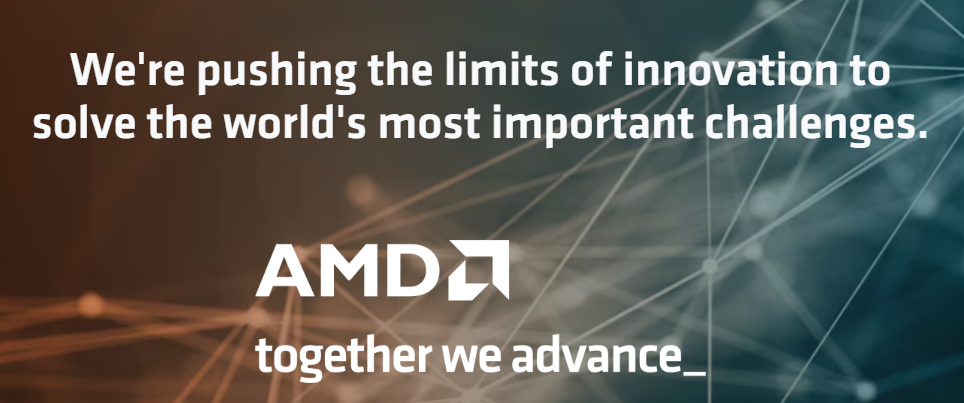

In [ ]:
pil_image = Image.open("together_we_advance_.png")
pil_image

初始化 ImageInference 实例：

In [ ]:
inference = ImageInference()

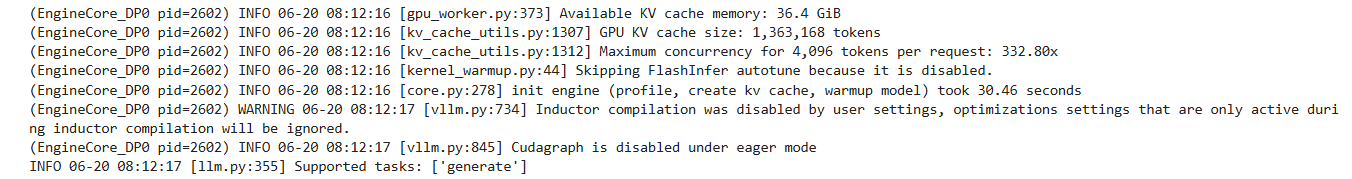

将图像传入模型进行推理并打印结果：

In [ ]:
# Generate output for the image
output = inference.generate_image_output(pil_image)

# Print the result
print("Model Output:")
print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Model Output:
We're pushing the limits of innovation to solve the world's most important challenges.

AMD

together we advance


恭喜您！您刚刚成功构建了一个 OCR 系统。创建一个能够转录给定图像中文字内容的 OCR 系统其实非常简单。

## 六. 扩展为支持多模型选择的 GUI 系统

为聊天机器人提供图形界面，可使用 **Gradio** 构建交互式 Web UI。

### 1.导入 Gradio 并定义可选 VLM 模型列表

以下代码预置了若干可用于图像分析的模型。完整支持列表见 [vLLM 官方文档](https://docs.vllm.ai/en/latest/models/supported_models.html)。

In [ ]:
import gradio as gr

# Define available models and their Hugging Face model IDs
MODEL_OPTIONS = {
    "Llama-3.2-11B-Vision-Instruct": "meta-llama/Llama-3.2-11B-Vision-Instruct",
    "BLIP-2 (2.7B)": "Salesforce/blip2-opt-2.7b",
    "BLIP-2 (6.7B)": "Salesforce/blip2-opt-6.7b",
    "Fuyu (8B)": "adept/fuyu-8b",
    "GLM-4V (9B)": "THUDM/glm-4v-9b",
    "H2OVL Mississippi (2B)": "h2oai/h2ovl-mississippi-2b",
    "H2OVL Mississippi (800M)": "h2oai/h2ovl-mississippi-800m",
    "InternVL2 (4B)": "OpenGVLab/InternVL2-4B",
    "InternVL2 (2B)": "OpenGVLab/Mono-InternVL-2B",
    "LLaVA 1.5 (7B)": "llava-hf/llava-1.5-7b-hf",
    "LLaVA 1.5 (13B)": "llava-hf/llava-1.5-13b-hf",
    "MiniCPM-V (2_5)": "openbmb/MiniCPM-Llama3-V-2_5",
    "MiniCPM-V (2)": "openbmb/MiniCPM-V-2",
    "Molmo (7B)": "allenai/Molmo-7B-D-0924",
    "PaliGemma (3B PT)": "google/paligemma-3b-pt-224",
    "PaliGemma (3B Mix)": "google/paligemma-3b-mix-224",
    "Phi-3 Vision (128K)": "microsoft/Phi-3-vision-128k-instruct",
    "Phi-3.5 Vision": "microsoft/Phi-3.5-vision-instruct",
    "Pixtral (12B)": "mistralai/Pixtral-12B-2409",
    "Qwen-VL": "Qwen/Qwen-VL",
    "Qwen-VL-Chat": "Qwen/Qwen-VL-Chat",
    "Qwen2-VL (2B)": "Qwen/Qwen2-VL-2B-Instruct",
    "Qwen2-VL (7B)": "Qwen/Qwen2-VL-7B-Instruct",
}

### 2.创建 Gradio 界面

定义模型切换与图像推理两个辅助函数，并构建 Gradio Blocks 界面：

In [ ]:
def switch_model(model_name):
    global inference
    try:
        inference = ImageInference(model_name=model_name)
        return f"Switched to model: {model_name}"
    except Exception as e:
        return f"Failed to switch model: {str(e)}"

def analyze_image(image):
    try:
        result = inference.generate_image_output(image)
        return result
    except Exception as e:
        return f"Error processing the image: {str(e)}"

with gr.Blocks() as interface:
    gr.Markdown("## Multimodal OCR & Image Analysis")
    
    with gr.Row():
        model_dropdown = gr.Dropdown(
            choices=list(MODEL_OPTIONS.keys()),
            value="Qwen2-VL-2B-Instruct",
            label="Select Model",
        )
        switch_button = gr.Button("Switch Model")

    model_status = gr.Textbox(value=f"Current Model: {current_model}", label="Model Status")

    image_input = gr.Image(type="pil", label="Upload Image")
    analyze_button = gr.Button("Analyze Image")
    # output_box = gr.Textbox(label="Model Output", lines=10)
    output_box = gr.Markdown(label="Model Output")

    switch_button.click(
        fn=lambda selected_model: (switch_model(MODEL_OPTIONS[selected_model]), f"Current Model: {MODEL_OPTIONS[selected_model]}"),
        inputs=[model_dropdown],
        outputs=[model_status, model_status],
    )
    analyze_button.click(fn=analyze_image, inputs=image_input, outputs=output_box)

/opt/venv/lib/python3.12/site-packages/gradio/components/dropdown.py:235: UserWarning: The value passed into gr.Dropdown() is not in the list of choices. Please update the list of choices to include: Qwen2-VL-2B-Instruct or set allow_custom_value=True.
  warnings.warn(


### 3.运行 Gradio 应用

下载cloudflared：目的是外部用户通过 cloudflared 服务器与当前使用的服务器建立的加密隧道，连接到当前使用的服务器。Gradio 服务在容器内监听 0.0.0.0:7860，接受本机所有来源的连接，由于平台只对外开放 8888、不能直接从公网访问 7860。所以本教程用 cloudflared 建一条出站隧道，让 cloudflared 去连容器内的 http://localhost:7860，把它映射成一个公网可访问的 https://xxx.trycloudflare.com 地址，然后在自己电脑的浏览器打开这个地址，就能用到容器里的服务。

In [ ]:
!wget --no-check-certificate https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64

--2026-06-20 09:01:54--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 36.151.243.83
Connecting to github.com (github.com)|36.151.243.83|:443... connected.
  Self-signed certificate encountered.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.6.1/cloudflared-linux-amd64 [following]
--2026-06-20 09:01:54--  https://github.com/cloudflare/cloudflared/releases/download/2026.6.1/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/74ac6867-a1bf-4352-b955-c16fbb86d0f6?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-20T10%3A01%3A53Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997

In [ ]:
!chmod +x cloudflared-linux-amd64
!./cloudflared-linux-amd64 --version

cloudflared version 2026.6.1 (built 2026-06-18-14:33 UTC)


> **说明**：server_port=7860：Gradio 实际监听的端口。

执行以下代码块，让 gradio 启动在 7860端口。

In [ ]:
interface.launch(server_name="0.0.0.0", server_port=7860)

* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.


起隧道，拿公网地址。

In [ ]:
import subprocess, time, re, threading

CF = "./cloudflared-linux-amd64"   # 若在 /tmp 则改成 "/tmp/cloudflared"

proc = subprocess.Popen(
    [CF, "tunnel", "--url", "http://localhost:7860"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1
)

url_found = None
def reader():
    global url_found
    for line in proc.stdout:
        print(line, end="")
        m = re.search(r"https://[-\w]+\.trycloudflare\.com", line)
        if m and not url_found:
            url_found = m.group(0)

threading.Thread(target=reader, daemon=True).start()
time.sleep(12)
print("\n>>> 你的公网地址:", url_found)

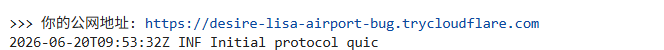

> **说明**：在浏览器上访问https://XXXXXX.trycloudflare.com，
GUI界面会在您的浏览器中显示，使您能够与 OCR 系统进行交互。选择模型上传图片，点击Analyze Image解析图片。

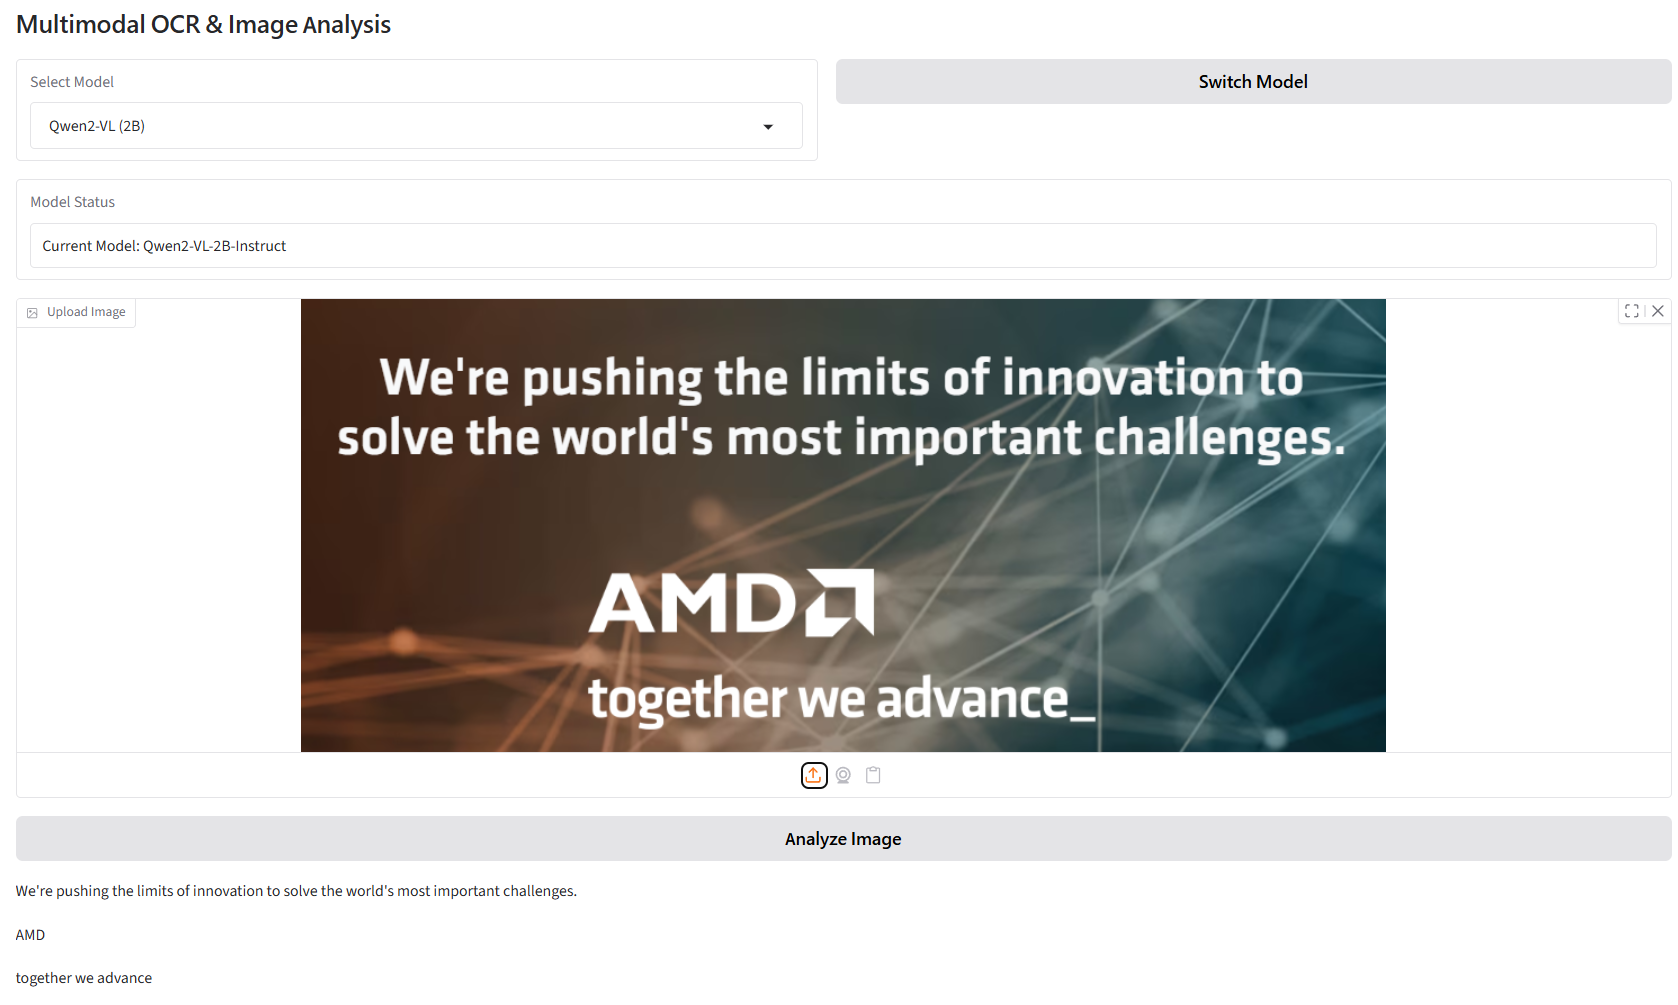

## 七.进阶实验：升级到更高质量的 OCR 模型（可选）

本教程主路径采用的是通用的 `Qwen/Qwen2-VL-2B-Instruct`。它图文通用，但 OCR 并非其最强项。如果你想要更高的识别准确率（多语种、表格、手写、公式、长文档版面），可按**显存预算**选择以下升级。模型权重与加载配置都不同：

| 模型 | 说明 | 显存建议 | 工作流 |
|------|------|---------|--------|
| `Qwen/Qwen2-VL-2B-Instruct` | 最轻量，常规印刷体 OCR 够用，显存最省 | 8–12GB | 仅替换 `current_model`，沿用本教程流程 |
| `Qwen/Qwen2.5-VL-7B-Instruct`（推荐） | OCR 准确率显著优于 11B Vision，多语种 / 表格 / 手写更稳 | 18–24GB | 同上，需 `transformers≥4.49` 与较新 vLLM |
| `meta-llama/Llama-3.2-11B-Vision-Instruct` | 通用图文，OCR 中等，作为对照基线 | 约 24GB | 沿用本教程流程 |
| `OpenGVLab/InternVL2_5-8B` | 文档版面与长文本理解强，复杂排版表现好 | 18–24GB | 同上，按模型卡设置图像分块 |
| `Qwen/Qwen2.5-VL-72B-Instruct-AWQ` | 当前可达的 OCR 天花板，复杂版面 / 公式 | bf16≈140GB（多卡）；AWQ≈40GB | 需 `tensor_parallel_size` 或量化权重；单卡 MI300X（192GB）可跑 bf16 全量 |

> Qwen2.5-VL / InternVL2.5 等较新模型对 `transformers` 与 `vllm` 版本有要求，加载前请按各自模型卡调整 `max_model_len`、图像预处理与（必要时）`tensor_parallel_size`。优先用**软件手段**压低显存（量化权重、降低 `max_num_seqs` 与 `max_model_len`），仍不够再考虑多卡或更大显存的硬件。


## 课后测验

**第 1 题：** 在宿主机上用 `docker run` 创建本教程容器时，下面哪一组参数的主要作用是**让容器能访问 AMD GPU**？

- A. `--ipc=host` 与 `--shm-size=16g`
- B. `--device=/dev/kfd` 与 `--device=/dev/dri`（并配合 `--group-add video`）
- C. `-p 8888:8888` 与 `-w /workspace/repo`
- D. `--env MODELSCOPE_CACHE=/workspace/modelscope`

**第 2 题：** 本教程为什么用 **ModelScope（魔搭社区）** 的 `snapshot_download` 下载 `Qwen2-VL-2B-Instruct` 权重？

- A. ModelScope 是唯一托管该模型的平台
- B. 只有 ModelScope 下载的权重才兼容 vLLM
- C. 国内访问速度快、稳定，且无需 token 验证；并可用 `local_dir` 指定保存到 `/workspace/repo/Qwen2-VL-2B-Instruct`
- D. ModelScope 会自动把权重量化成 AWQ 以节省显存

**第 3 题：** 在 **W7900（48GB 显存）** 上想提升 OCR 准确率、要换更大的模型，下面哪种做法符合"先软件、后硬件"原则？

- A. 直接换成 `Qwen2.5-VL-72B-Instruct`
- B. 立即换一张显存更大的卡
- C. 先用软件手段在 48GB 内压显存——权重量化（AWQ/GPTQ）、调低 `max_model_len`（如 4096→2048）、调低 `max_num_seqs`，这些都不够再考虑换卡
- D. 直接上多卡并行


<details>
<summary><b>点击查看答案与解析</b></summary>

1. **B**。`--device=/dev/kfd` 和 `--device=/dev/dri` 把 AMD 的内核计算接口与渲染设备暴露给容器，再配合 `--group-add video` 赋予访问权限，容器内才能用上 GPU（进容器执行 `torch.cuda.is_available()` 返回 `True` 即说明可获取 GPU）。`--ipc=host`/`--shm-size` 是共享内存设置，`-p`/`-w` 是端口映射与工作目录，`MODELSCOPE_CACHE` 是模型缓存路径，均与 GPU 访问无直接关系。

2. **C**。教程明确指出用 ModelScope 下载是因为国内访问速度快、稳定且无需 token 验证，并通过 `snapshot_download(..., local_dir='/workspace/repo/Qwen2-VL-2B-Instruct')` 把权重落到指定目录。模型在 Hugging Face 等平台同样有托管，权重也不是只有 ModelScope 才兼容 vLLM，下载本身也不做量化。

3. **C**。框架强调"软件优化优先于硬件升级"：先用量化、调低 `max_model_len` 和 `max_num_seqs` 等软件手段在 48GB 内压显存；确实不够时才换更大显存的卡。直接换 72B（bf16≈140GB、AWQ≈40GB+）在单卡 48GB 上显存吃紧、难以稳定运行。

</details>